### 1c. Launch Jupyter and run the verification cell


In [1]:
import torch
import torchvision

# Check versions
print("PyTorch version:", torch.__version__)
print("TorchVision version:", torchvision.__version__)

# Check whether a GPU is available (we expect CPU for this project)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.6.0+cpu
TorchVision version: 0.21.0+cpu
Using device: cpu


### Step 2: loading and exploring the CIFAR-10 dataset.

### 2a. Download and load CIFAR-10

In [3]:
import torchvision
import torchvision.transforms as transforms

# For now, just convert images to tensors so we can inspect them.
# (Full preprocessing/normalization comes in Step 3.)
basic_transform = transforms.ToTensor()

# Download the training set (50,000 images)
train_dataset = torchvision.datasets.CIFAR10(
    root="../data/raw",
    train=True,
    download=True,
    transform=basic_transform
)

# Download the test set (10,000 images)
test_dataset = torchvision.datasets.CIFAR10(
    root="../data/raw",
    train=False,
    download=True,
    transform=basic_transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100.0%


Training samples: 50000
Test samples: 10000


### 2b. Inspect one sample and the class names


In [5]:
# Grab the first training example: an (image_tensor, label) pair
image, label = train_dataset[0]

# The 10 CIFAR-10 class names, in their official label order (0-9)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Image tensor shape:", image.shape)
print("Pixel value range: min =", image.min().item(), " max =", image.max().item())
print("Label (number):", label)
print("Label (class name):", class_names[label])

Image tensor shape: torch.Size([3, 32, 32])
Pixel value range: min = 0.0  max = 1.0
Label (number): 6
Label (class name): frog


### 2c check class balance

In [6]:
import numpy as np

# Pull all training labels into a NumPy array
train_labels = np.array(train_dataset.targets)

# Count how many images belong to each class
unique, counts = np.unique(train_labels, return_counts=True)

print("Images per class in the training set:")
for class_index, count in zip(unique, counts):
    print(f"  {class_names[class_index]:<12} : {count}")

Images per class in the training set:
  airplane     : 5000
  automobile   : 5000
  bird         : 5000
  cat          : 5000
  deer         : 5000
  dog          : 5000
  frog         : 5000
  horse        : 5000
  ship         : 5000
  truck        : 5000


### 2d. Visualize sample images

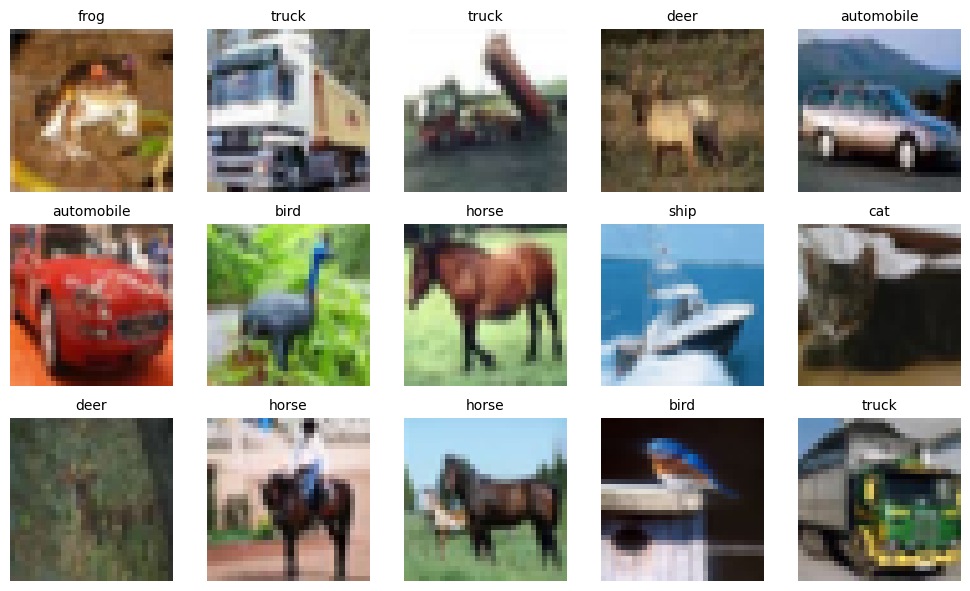

In [7]:
import matplotlib.pyplot as plt

# Set up a 3x5 grid to show 15 sample images
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for ax, idx in zip(axes.flatten(), range(15)):
    image, label = train_dataset[idx]
    # Tensor is [C, H, W]; matplotlib wants [H, W, C], so permute the axes
    image = image.permute(1, 2, 0)
    ax.imshow(image)
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()

# Save the figure to your outputs folder for the README later
plt.savefig("../outputs/figures/cifar10_samples.png", dpi=100, bbox_inches="tight")
plt.show()

### Step 3 — Preprocessing: normalization + train/validation/test splits with DataLoaders

### 3a. Define the normalization transform and reload the datasets

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms

# CIFAR-10's per-channel mean and standard deviation (R, G, B).
# These are well-established, precomputed values for this specific dataset.
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

# Transform pipeline: convert to tensor, THEN normalize using the stats above.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])

# Reload both splits with the normalization transform applied.
# (Already downloaded in Step 2, so this just reuses the cached files.)
train_full = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="../data/raw", train=False, download=True, transform=transform
)

print("Full training set:", len(train_full))
print("Test set:", len(test_dataset))

Full training set: 50000
Test set: 10000


### 3b. Split the training data into train + validation

In [10]:
from torch.utils.data import random_split

# Reserve 10,000 images for validation, keep 40,000 for training.
val_size = 10000
train_size = len(train_full) - val_size   # 50000 - 10000 = 40000

# Use a fixed random seed so the split is the same every time we run this
# (reproducibility — important for a portfolio project).
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], generator=generator
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 40000
Validation samples: 10000
Test samples: 10000


### 3c. Create the DataLoaders

In [11]:
from torch.utils.data import DataLoader

# Batch size: how many images the model sees at once. 64 is a solid,
# CPU-friendly choice for CIFAR-10.
batch_size = 64

# Training loader: shuffle=True so the model sees images in a fresh order
# each epoch (helps it generalize instead of memorizing sequence).
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Validation & test loaders: shuffle=False — order doesn't matter for
# evaluation, and keeping it fixed makes results consistent.
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Batches per epoch (train):", len(train_loader))
print("Batches (validation):", len(val_loader))
print("Batches (test):", len(test_loader))

Batches per epoch (train): 625
Batches (validation): 157
Batches (test): 157


### 3d. Sanity-check one batch

In [12]:
# Pull a single batch from the training loader to confirm shapes are right.
images, labels = next(iter(train_loader))

print("One batch of images shape:", images.shape)
print("One batch of labels shape:", labels.shape)
print("Pixel range after normalization: min =",
      round(images.min().item(), 2), " max =", round(images.max().item(), 2))

One batch of images shape: torch.Size([64, 3, 32, 32])
One batch of labels shape: torch.Size([64])
Pixel range after normalization: min = -1.99  max = 2.13


### STEP-4 DATA AUGMENTATION

### 4a. Define separate transforms for training and evaluation

In [13]:
import torchvision.transforms as transforms

# CIFAR-10 normalization stats (same as before)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

# TRAINING transform: augmentation + normalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])

# EVALUATION transform: just normalization, no augmentation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])

print("Transforms ready.")

Transforms ready.


### 4b. Rebuild the datasets and splits with the new transforms

In [14]:
import torch
import torchvision
from torch.utils.data import random_split, DataLoader

# Load training data with AUGMENTATION, test data with plain eval transform
train_full_aug = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="../data/raw", train=False, download=True, transform=eval_transform
)

# Same 40k / 10k split as Step 3, using the same seed for reproducibility
val_size = 10000
train_size = len(train_full_aug) - val_size
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_full_aug, [train_size, val_size], generator=generator
)

# Rebuild DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 625
Val batches: 157
Test batches: 157


### 4c. Visualize augmentation in action

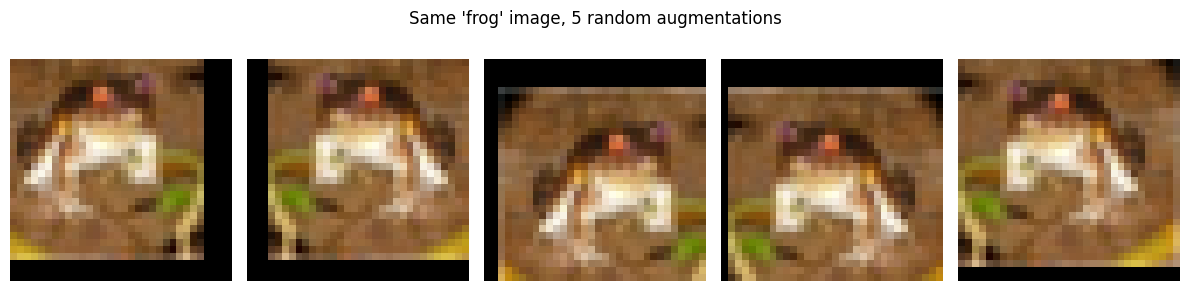

In [15]:
import matplotlib.pyplot as plt

# Show the SAME image 5 times to see the random augmentation vary each time.
# We grab the raw image (before transforms) then apply train_transform manually.
raw_dataset = torchvision.datasets.CIFAR10(root="../data/raw", train=True, download=True)
raw_image, raw_label = raw_dataset[0]

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax in axes:
    augmented = train_transform(raw_image)          # apply random augmentation
    img = augmented.permute(1, 2, 0)                # [C,H,W] -> [H,W,C]
    img = img * torch.tensor(cifar10_std) + torch.tensor(cifar10_mean)  # un-normalize for viewing
    img = img.clamp(0, 1)                           # keep pixel values in valid range
    ax.imshow(img)
    ax.axis("off")

fig.suptitle(f"Same '{class_names[raw_label]}' image, 5 random augmentations")
plt.tight_layout()
plt.savefig("../outputs/figures/augmentation_examples.png", dpi=100, bbox_inches="tight")
plt.show()

### Step 5 — Building the CNN from scratch

### 5a. Define the CNN class

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # --- Convolutional block 1 ---
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # --- Convolutional block 2 ---
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # --- Convolutional block 3 ---
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Pooling shrinks the image by half each time it's used
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout randomly switches off some neurons to fight overfitting
        self.dropout = nn.Dropout(0.25)

        # --- Fully connected (dense) layers ---
        # After 3 poolings, 32x32 image becomes 4x4 with 128 channels: 128*4*4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1: conv -> batchnorm -> relu -> pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32x32 -> 16x16
        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16x16 -> 8x8
        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8x8 -> 4x4

        # Flatten the 3D feature maps into a 1D vector for the dense layers
        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                                  # final scores for 10 classes
        return x

# Create the model and move it to our device (CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=10).to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


### 5b. Count the model's parameters

In [17]:
# Count how many values the model will learn during training
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     620,810
Trainable parameters: 620,810


### Step 6 — Compiling and training the model

### 6a. Fix the validation data, then set up the loss and optimizer

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import random_split, DataLoader, Subset

# Load the training data TWICE: one augmented, one clean.
train_data_aug   = torchvision.datasets.CIFAR10(root="../data/raw", train=True,
                                                download=True, transform=train_transform)
train_data_clean = torchvision.datasets.CIFAR10(root="../data/raw", train=True,
                                                download=True, transform=eval_transform)

# Split indices with the same seed so both versions split identically.
val_size = 10000
train_size = len(train_data_aug) - val_size
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(range(len(train_data_aug)),
                                         [train_size, val_size], generator=generator)

# Training uses AUGMENTED images; validation uses CLEAN images.
train_dataset = Subset(train_data_aug,   train_subset.indices)
val_dataset   = Subset(train_data_clean, val_subset.indices)

# Rebuild the loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# The loss function and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Data rebuilt: training is augmented, validation is clean.")
print("Loss function and optimizer ready.")

Data rebuilt: training is augmented, validation is clean.
Loss function and optimizer ready.


### 6b. Write the train and validate helper functions

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                      # put model in training mode
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass: model makes guesses
        loss = criterion(outputs, labels)  # measure how wrong it was
        loss.backward()                # backpropagation: compute gradients
        optimizer.step()               # update the model's weights

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # pick the highest-scoring class
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()                       # put model in evaluation mode
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():              # don't track gradients (faster, saves memory)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc

print("Training and evaluation functions ready.")

Training and evaluation functions ready.


### 6c. Run the training loop

In [20]:
num_epochs = 15
best_val_acc = 0.0

# Lists to record history for plotting later (Step 7)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Starting training...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{num_epochs}  "
          f"| Train loss: {train_loss:.3f}, acc: {train_acc:5.2f}%  "
          f"| Val loss: {val_loss:.3f}, acc: {val_acc:5.2f}%")

    # Save the model whenever validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "../models/best_cnn.pth")
        print(f"   -> New best model saved (val acc: {val_acc:.2f}%)")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch  1/15  | Train loss: 1.534, acc: 44.13%  | Val loss: 1.148, acc: 58.68%
   -> New best model saved (val acc: 58.68%)
Epoch  2/15  | Train loss: 1.223, acc: 55.77%  | Val loss: 0.969, acc: 65.21%
   -> New best model saved (val acc: 65.21%)
Epoch  3/15  | Train loss: 1.092, acc: 60.77%  | Val loss: 0.909, acc: 67.29%
   -> New best model saved (val acc: 67.29%)
Epoch  4/15  | Train loss: 1.020, acc: 63.93%  | Val loss: 0.857, acc: 69.85%
   -> New best model saved (val acc: 69.85%)
Epoch  5/15  | Train loss: 0.958, acc: 66.23%  | Val loss: 0.889, acc: 68.13%
Epoch  6/15  | Train loss: 0.920, acc: 67.64%  | Val loss: 0.778, acc: 71.92%
   -> New best model saved (val acc: 71.92%)
Epoch  7/15  | Train loss: 0.883, acc: 69.00%  | Val loss: 0.757, acc: 73.11%
   -> New best model saved (val acc: 73.11%)
Epoch  8/15  | Train loss: 0.851, acc: 70.11%  | Val loss: 0.767, acc: 72.55%
Epoch  9/15  | Train loss: 0.827, acc: 71.07%  | Val loss: 0.724, acc: 74.72%
   -> 

### Step 7 — Evaluating the model

### 7a. Plot the learning curves

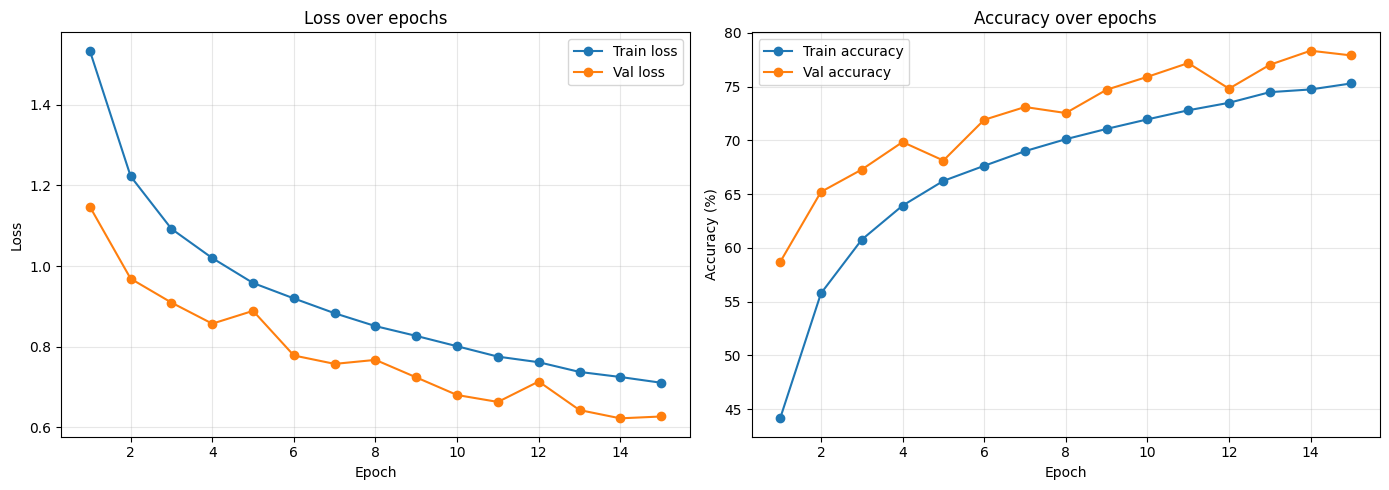

In [21]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve ---
ax1.plot(epochs_range, history["train_loss"], label="Train loss", marker="o")
ax1.plot(epochs_range, history["val_loss"],   label="Val loss",   marker="o")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy curve ---
ax2.plot(epochs_range, history["train_acc"], label="Train accuracy", marker="o")
ax2.plot(epochs_range, history["val_acc"],   label="Val accuracy",   marker="o")
ax2.set_title("Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/learning_curves.png", dpi=100, bbox_inches="tight")
plt.show()

### 7b. Get predictions on the test set

In [22]:
import torch

# Load the best saved model weights
model.load_state_dict(torch.load("../models/best_cnn.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Overall test accuracy
correct = sum(p == l for p, l in zip(all_preds, all_labels))
test_acc = 100.0 * correct / len(all_labels)
print(f"Test accuracy: {test_acc:.2f}%")

Test accuracy: 78.08%


### 7c. Build the confusion matrix

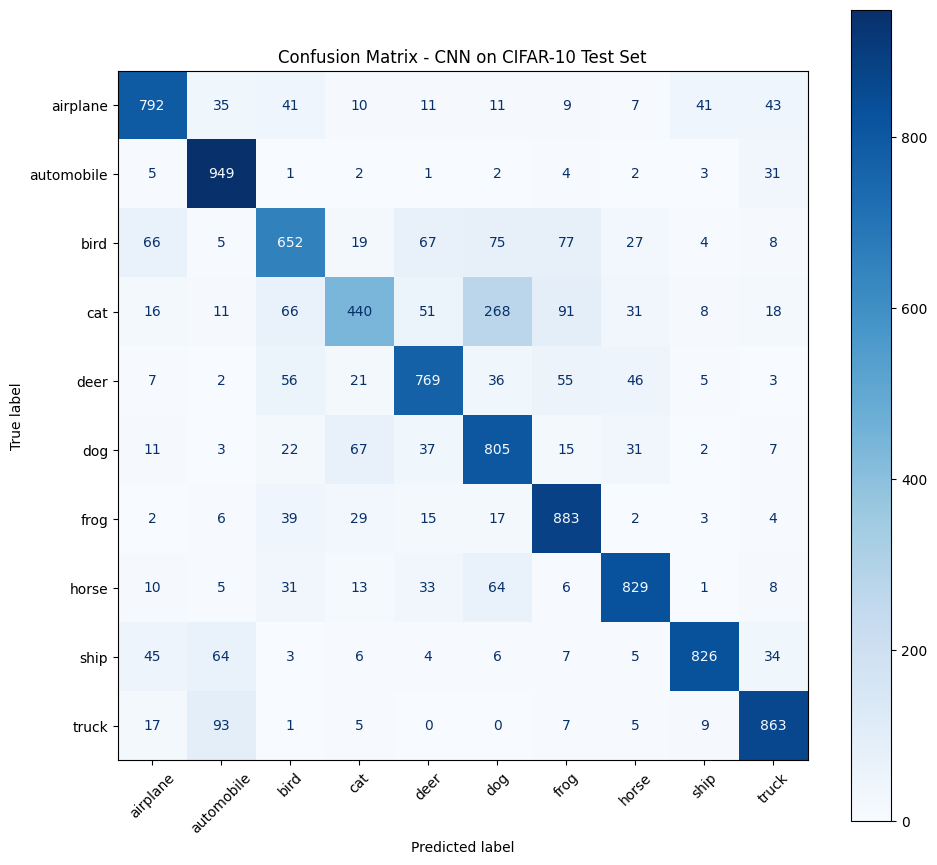

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Build the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
ax.set_title("Confusion Matrix - CNN on CIFAR-10 Test Set")

plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

### 7d. Print the classification report

In [25]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds,
                               target_names=class_names, digits=3)
print(report)

              precision    recall  f1-score   support

    airplane      0.816     0.792     0.804      1000
  automobile      0.809     0.949     0.873      1000
        bird      0.715     0.652     0.682      1000
         cat      0.719     0.440     0.546      1000
        deer      0.778     0.769     0.774      1000
         dog      0.627     0.805     0.705      1000
        frog      0.765     0.883     0.820      1000
       horse      0.842     0.829     0.835      1000
        ship      0.916     0.826     0.869      1000
       truck      0.847     0.863     0.855      1000

    accuracy                          0.781     10000
   macro avg      0.783     0.781     0.776     10000
weighted avg      0.783     0.781     0.776     10000



### Step 8 — Transfer learning

### 8a. New data pipeline for the pretrained model

In [32]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader, Subset

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

# 128x128: a good middle ground -- stronger than 96, faster than 224
tl_train_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

tl_eval_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

tl_train_aug   = torchvision.datasets.CIFAR10(root="../data/raw", train=True,
                                              download=True, transform=tl_train_transform)
tl_train_clean = torchvision.datasets.CIFAR10(root="../data/raw", train=True,
                                              download=True, transform=tl_eval_transform)
tl_test        = torchvision.datasets.CIFAR10(root="../data/raw", train=False,
                                              download=True, transform=tl_eval_transform)

val_size = 10000
train_size = len(tl_train_aug) - val_size
generator = torch.Generator().manual_seed(42)
tl_train_subset, tl_val_subset = random_split(range(len(tl_train_aug)),
                                              [train_size, val_size], generator=generator)

tl_train_dataset = Subset(tl_train_aug,   tl_train_subset.indices)
tl_val_dataset   = Subset(tl_train_clean, tl_val_subset.indices)

tl_batch_size = 32
tl_train_loader = DataLoader(tl_train_dataset, batch_size=tl_batch_size, shuffle=True)
tl_val_loader   = DataLoader(tl_val_dataset,   batch_size=tl_batch_size, shuffle=False)
tl_test_loader  = DataLoader(tl_test,          batch_size=tl_batch_size, shuffle=False)

print("Transfer-learning pipeline ready (128x128 images).")
print("Train batches:", len(tl_train_loader), "| Val batches:", len(tl_val_loader), "| Test batches:", len(tl_test_loader))

Transfer-learning pipeline ready (128x128 images).
Train batches: 1250 | Val batches: 313 | Test batches: 313


### 8b. Load ResNet18 and adapt it

In [33]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tl_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# First freeze EVERYTHING
for param in tl_model.parameters():
    param.requires_grad = False

# Then UNFREEZE just the last block (layer4) so it can adapt to CIFAR-10
for param in tl_model.layer4.parameters():
    param.requires_grad = True

# Replace the final layer (this is trainable by default)
num_features = tl_model.fc.in_features
tl_model.fc = nn.Linear(num_features, 10)

tl_model = tl_model.to(device)

trainable = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in tl_model.parameters())
print(f"Trainable parameters: {trainable:,} out of {total:,}")
print("Training layer4 + final layer -- enough power to adapt, still efficient.")

Trainable parameters: 8,398,858 out of 11,181,642
Training layer4 + final layer -- enough power to adapt, still efficient.


### 8c. Train the transfer-learning model

In [36]:
import torch
import torch.optim as optim

tl_criterion = nn.CrossEntropyLoss()
tl_optimizer = optim.Adam(filter(lambda p: p.requires_grad, tl_model.parameters()), lr=0.0005)

tl_num_epochs = 6
tl_best_val_acc = 0.0
tl_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Starting transfer-learning training (layer4 unfrozen)...\n")

for epoch in range(tl_num_epochs):
    train_loss, train_acc = train_one_epoch(tl_model, tl_train_loader, tl_criterion, tl_optimizer, device)
    val_loss, val_acc     = evaluate(tl_model, tl_val_loader, tl_criterion, device)

    tl_history["train_loss"].append(train_loss)
    tl_history["train_acc"].append(train_acc)
    tl_history["val_loss"].append(val_loss)
    tl_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{tl_num_epochs}  "
          f"| Train loss: {train_loss:.3f}, acc: {train_acc:5.2f}%  "
          f"| Val loss: {val_loss:.3f}, acc: {val_acc:5.2f}%")

    if val_acc > tl_best_val_acc:
        tl_best_val_acc = val_acc
        torch.save(tl_model.state_dict(), "../models/best_resnet18.pth")
        print(f"   -> New best model saved (val acc: {val_acc:.2f}%)")

print(f"\nTransfer learning complete. Best validation accuracy: {tl_best_val_acc:.2f}%")

Starting transfer-learning training (layer4 unfrozen)...

Epoch 1/6  | Train loss: 0.068, acc: 97.72%  | Val loss: 0.327, acc: 90.79%
   -> New best model saved (val acc: 90.79%)
Epoch 2/6  | Train loss: 0.057, acc: 98.08%  | Val loss: 0.307, acc: 91.71%
   -> New best model saved (val acc: 91.71%)
Epoch 3/6  | Train loss: 0.052, acc: 98.23%  | Val loss: 0.331, acc: 91.31%
Epoch 4/6  | Train loss: 0.048, acc: 98.46%  | Val loss: 0.331, acc: 91.61%
Epoch 5/6  | Train loss: 0.040, acc: 98.63%  | Val loss: 0.330, acc: 91.74%
   -> New best model saved (val acc: 91.74%)
Epoch 6/6  | Train loss: 0.037, acc: 98.71%  | Val loss: 0.363, acc: 91.36%

Transfer learning complete. Best validation accuracy: 91.74%


### 8d. Test the transfer-learning model

In [38]:
 # Load best transfer-learning weights
tl_model.load_state_dict(torch.load("../models/best_resnet18.pth"))
tl_model.eval()

tl_all_preds, tl_all_labels = [], []

with torch.no_grad():
    for images, labels in tl_test_loader:
        images = images.to(device)
        outputs = tl_model(images)
        _, predicted = outputs.max(1)
        tl_all_preds.extend(predicted.cpu().numpy())
        tl_all_labels.extend(labels.numpy())

tl_correct = sum(p == l for p, l in zip(tl_all_preds, tl_all_labels))
tl_test_acc = 100.0 * tl_correct / len(tl_all_labels)

print(f"Scratch CNN test accuracy:       ~78%")
print(f"Transfer learning test accuracy: {tl_test_acc:.2f}%")
print(f"Improvement: about +{tl_test_acc - 78:.1f} percentage points")

Scratch CNN test accuracy:       ~78%
Transfer learning test accuracy: 91.71%
Improvement: about +13.7 percentage points


### Step 9 — Saving the final model for deployment

### 9a. Re-save the best model cleanly with its info

In [39]:
import torch
import torch.nn as nn
from torchvision import models
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild the same ResNet18 structure we trained
final_model = models.resnet18(weights=None)   # no pretrained weights needed now
num_features = final_model.fc.in_features
final_model.fc = nn.Linear(num_features, 10)

# Load our best trained weights into it
final_model.load_state_dict(torch.load("../models/best_resnet18.pth", map_location=device))
final_model.eval()

# Save a clean copy for deployment
torch.save(final_model.state_dict(), "../models/cifar10_resnet18_final.pth")

# Save the info the web app will need, as a small JSON file
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

model_info = {
    "model_architecture": "resnet18",
    "num_classes": 10,
    "class_names": class_names,
    "image_size": 128,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225]
}

with open("../models/model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Final model saved: cifar10_resnet18_final.pth")
print("Model info saved:  model_info.json")

Final model saved: cifar10_resnet18_final.pth
Model info saved:  model_info.json


### 9b. Verify the saved model loads and predicts correctly

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the info file
with open("../models/model_info.json", "r") as f:
    info = json.load(f)

# Rebuild the model structure from the info and load the final weights
check_model = models.resnet18(weights=None)
check_model.fc = nn.Linear(check_model.fc.in_features, info["num_classes"])
check_model.load_state_dict(torch.load("../models/cifar10_resnet18_final.pth", map_location=device))
check_model.eval()

# Grab one test image and predict its class
test_images, test_labels = next(iter(tl_test_loader))
one_image = test_images[0].unsqueeze(0).to(device)   # a single image
true_label = test_labels[0].item()

with torch.no_grad():
    output = check_model(one_image)
    probs = F.softmax(output, dim=1)              # turn scores into probabilities
    confidence, pred = probs.max(1)

print("Predicted class:", info["class_names"][pred.item()])
print("True class:     ", info["class_names"][true_label])
print(f"Confidence:      {confidence.item()*100:.2f}%")

Predicted class: cat
True class:      cat
Confidence:      99.93%


### 9c. Create a single reusable prediction function

In [41]:
from PIL import Image
import torchvision.transforms as transforms

def predict_image(image_path, model, info, device):
    """Take an image file path, return the predicted class and confidence."""
    # Build the same transform used during evaluation
    transform = transforms.Compose([
        transforms.Resize(info["image_size"]),
        transforms.CenterCrop(info["image_size"]),
        transforms.ToTensor(),
        transforms.Normalize(info["imagenet_mean"], info["imagenet_std"])
    ])

    # Open the image, force RGB (handles grayscale/PNG-with-alpha safely)
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probs = F.softmax(output, dim=1)
        confidence, pred = probs.max(1)

    predicted_class = info["class_names"][pred.item()]
    return predicted_class, confidence.item() * 100


# Test the function on a saved sample image (reuse the one from Step 2)
import torchvision
raw_dataset = torchvision.datasets.CIFAR10(root="../data/raw", train=False, download=True)
sample_path = "../outputs/figures/test_sample.png"
raw_dataset[0][0].save(sample_path)   # save the first test image to a file

predicted_class, confidence = predict_image(sample_path, check_model, info, device)
print(f"Prediction for saved image: {predicted_class} ({confidence:.2f}% confidence)")
print("True class:", info["class_names"][raw_dataset[0][1]])

Prediction for saved image: cat (99.93% confidence)
True class: cat


### Step 10 — Building the Flask web app

### 10a. Copy the model files into src/